# Analyzing Patient No-Show Behavior in Medical Appointments Project
**Author:** Chanatip Srinaul  
**Date:** June 2025

## Executive Summary
Missed medical appointments (no-shows) lead to inefficiencies and increased operational costs for healthcare providers. This project analyzes patient appointment data to identify key factors associated with no-show behavior and provide actionable recommendations.

Using historical appointment records, exploratory data analysis was conducted to compare patient characteristics and appointment features between show and no-show cases.

### Key Insights
* Patients without SMS reminders are significantly more likely to miss their appointments.

* Longer waiting times between scheduling and appointment dates are associated with higher no-show rates.

* Younger patients exhibit a higher tendency to miss appointments compared to older age groups.

### Recommendations
* Implement targeted SMS reminder campaigns for high-risk patient groups.
* Prioritize follow-ups for appointments with long waiting times.
* Suggest flexible scheduling for younger patients.

## Introductions
Patient missed appointments are a common challenge in healthcare systems, leading to inefficient resource utilization and reduced quality of care. Understanding the factors that influence whether patients attend their scheduled appointments is essential for improving operational efficiency and patient outcomes.

## Objective
Analyze the patterns and insights related to patient no-shows by exploring various influencing factors such as gender, age, underlying medical conditions, SMS reminders, and the waiting time between scheduling and appointment day.
The goal is to uncover actionable insights that can help in planning strategies to reduce the no-show rate in the future and improve the efficiency of healthcare appointment systems.

## Key Questions
#### 1. What is the proportion of patients who showed up versus those who missed their appointments?
#### 2. What is the distribution of show vs. no-show patients by gender?
#### 3. What age group has the highest rate of missed appointments?
#### 4. Do most patients who missed their appointments have any underlying medical conditions?
#### 5. How many days do patients who missed their appointments have to wait from scheduling to the actual appointment date?
#### 6. Which day do most patients miss their appointments?
#### 7. Does receiving an SMS reminder influence the likelihood of attending the appointment?
#### 8. Which neighborhood has the highest number of no-show patients and did they receive SMS reminder?

## Content
110,527 medical appointments with 14 variables. The target variable is "No-show" which indicates whether the patient attended or missed their appointment.


## Data Dictionary
01 - PatientId -->
Identification of a patient

02 - AppointmentID -->
Identification of each appointment

03 - Gender -->
Male or Female

04 - ScheduledDay -->
The day someone called or registered the appointment, this is before appointment.

05 - AppointmentDay -->
The day of the actual appointment, when they have to visit the doctor.

06 - Age -->
How old is the patient.

07 - Neighbourhood -->
Where the appointment takes place.

08 - Scholarship -->
True of False

09 - Hypertension -->
True or False

10 - Diabetes -->
True or False

11 - Alcoholism -->
True or False

12 - Handicap -->
True or False

13 - SMS_received -->
True or False

14 - No_show -->
True or False.

## 1. Data Understanding

### Import dataset and perform an initial review to understand what data look like 

In [42]:
#Import libray and dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/User/Desktop/Medical Appointment.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [43]:
df.shape

(110527, 14)

In [44]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


* From an initial review, this dataset has no missing values but it does contain invalid values

## 2. Data Cleaning

### Next step is cleaning the data and create additional columns for futher analysis

In [46]:
#Copy df before clean
df_cleaned = df.copy()
df_cleaned.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [47]:
#Rename Columns
df_cleaned.rename(columns={'Hipertension':'Hypertension'},inplace=True)
df_cleaned.rename(columns={'Handcap':'Handicap'},inplace=True)
df_cleaned.rename(columns={'No-show':'No_show'},inplace=True)

In [48]:
#Check duplicated data 
df_cleaned.duplicated(['PatientId','No_show']).sum()

38710

In [49]:
#Drop duplicated row
df_cleaned = df_cleaned.drop_duplicates(['PatientId','No_show'])
df_cleaned.shape

(71817, 14)

In [83]:
#Replace values in No-show column from "Yes"/"No" to 1/0 and change datatype to int
df_cleaned['No_show'] = df_cleaned['No_show'].replace({'No':0,'Yes':1}).astype('int64')

In [51]:
#Convert 'ScheduledDay' and 'AppointmentDay' from object to datetime
df_cleaned['ScheduledDay'] = pd.to_datetime(df_cleaned['ScheduledDay']).dt.date.astype('datetime64[ns]')
df_cleaned['AppointmentDay'] = pd.to_datetime(df_cleaned['AppointmentDay']).dt.date.astype('datetime64[ns]')

In [52]:
#Create "WaitingDay" column
df_cleaned['WaitingDay'] = (df_cleaned['AppointmentDay'] - df_cleaned['ScheduledDay']).apply(lambda x: x.days)
df_cleaned['WaitingDay'].describe()

count    71817.000000
mean        11.166855
std         16.136069
min         -1.000000
25%          0.000000
50%          4.000000
75%         17.000000
max        179.000000
Name: WaitingDay, dtype: float64

In [53]:
#Drop rows that have invalid data in WaitingDay column
df_cleaned = df_cleaned.drop(df_cleaned[df_cleaned['WaitingDay']<0].index,axis=0)

In [54]:
#Create "Weekday" column
df_cleaned['Weekday'] = pd.to_datetime(df_cleaned['AppointmentDay']).dt.day_name()

In [55]:
#Check values in Gender and Handcap column
print(df_cleaned['Gender'].unique())
print()
print(df_cleaned['Handicap'].unique())

['F' 'M']

[0 1 2 3 4]


In [56]:
#Drop rows that have invalid age
df_cleaned = df_cleaned.drop(df_cleaned[df_cleaned['Age']<0].index,axis=0).reset_index(drop=True)

#Change values in the Handicap column from 2-4 to 1, so this column will contain true(1) or false(0) values
df_cleaned['Handicap'] = df_cleaned['Handicap'].apply(lambda x:1 if x in [2,3,4] else x)

In [57]:
#drop unused columns
df_cleaned = df_cleaned.drop(columns={'PatientId','AppointmentID','ScheduledDay','AppointmentDay'})
df_cleaned.head()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,WaitingDay,Weekday
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday


In [58]:
df_cleaned.shape

(71814, 12)

In [59]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71814 entries, 0 to 71813
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         71814 non-null  object
 1   Age            71814 non-null  int64 
 2   Neighbourhood  71814 non-null  object
 3   Scholarship    71814 non-null  int64 
 4   Hypertension   71814 non-null  int64 
 5   Diabetes       71814 non-null  int64 
 6   Alcoholism     71814 non-null  int64 
 7   Handicap       71814 non-null  int64 
 8   SMS_received   71814 non-null  int64 
 9   No_show        71814 non-null  int64 
 10  WaitingDay     71814 non-null  int64 
 11  Weekday        71814 non-null  object
dtypes: int64(9), object(3)
memory usage: 6.6+ MB


In [60]:
#no_show variable
no_show = df_cleaned[df_cleaned['No_show']==1]
no_show.shape

(17661, 12)

## 3. EDA

### Exploring the data in depth using visualization to find insights and answers to the questions we want

### 1. What is the proportion of patients who showed up versus those who missed their appointments?

In [61]:
#Proportion of patients who showed up and patients who missed their appointment
df_cleaned['No_show'].value_counts()

No_show
0    54153
1    17661
Name: count, dtype: int64

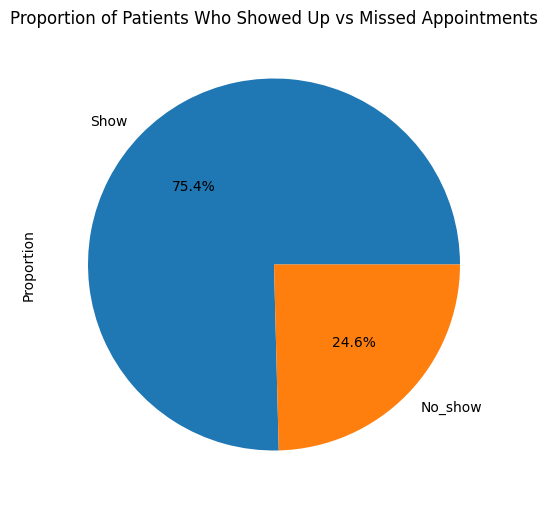

In [62]:
#Proportion of patients who showed up and patients who missed their appointment
plt.figure(figsize=(6,10))
df_cleaned['No_show'].value_counts(normalize=True).plot(kind='pie',labels=['Show','No_show'],autopct='%1.1f%%')
plt.title("Proportion of Patients Who Showed Up vs Missed Appointments")
plt.ylabel('Proportion')
plt.show()

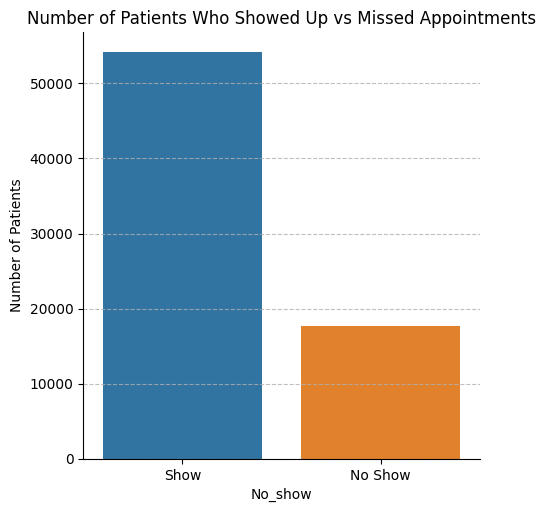

In [63]:
#The bar graph shows the number of patients who showed up and patients who missed their appointment
sns.catplot(data=df_cleaned,x='No_show',kind='count',hue='No_show',legend=False)
plt.title("Number of Patients Who Showed Up vs Missed Appointments")
plt.xticks(ticks=[0,1],labels=['Show','No Show'])
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.8)
plt.show()

### 2. What is the distribution of show vs. no-show patients by gender?

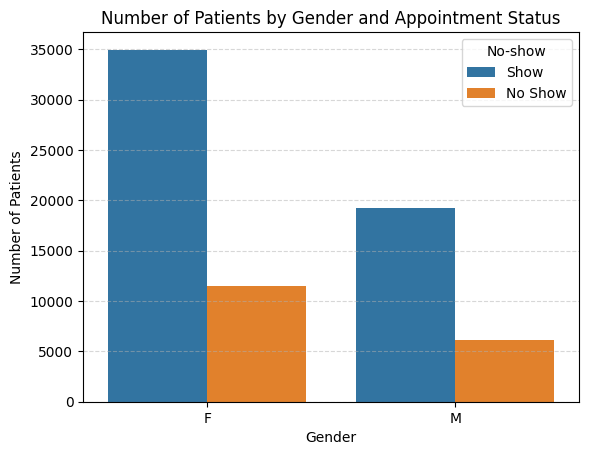

In [64]:
#the bar graph shows patients who showed up vs. missed their appointments by gender
sns.countplot(data=df_cleaned,x='Gender',hue='No_show')
plt.title('Number of Patients by Gender and Appointment Status')
plt.legend(title='No-show',labels=['Show','No Show'])
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [65]:
#proportion of patients who showed up vs. missed their appointments by gender
df_cleaned.groupby('Gender')['No_show'].value_counts(normalize=True).unstack()*100

No_show,0,1
Gender,,
F,75.237808,24.762192
M,75.718005,24.281995


### 3. What age group has the highest rate of missed appointments?

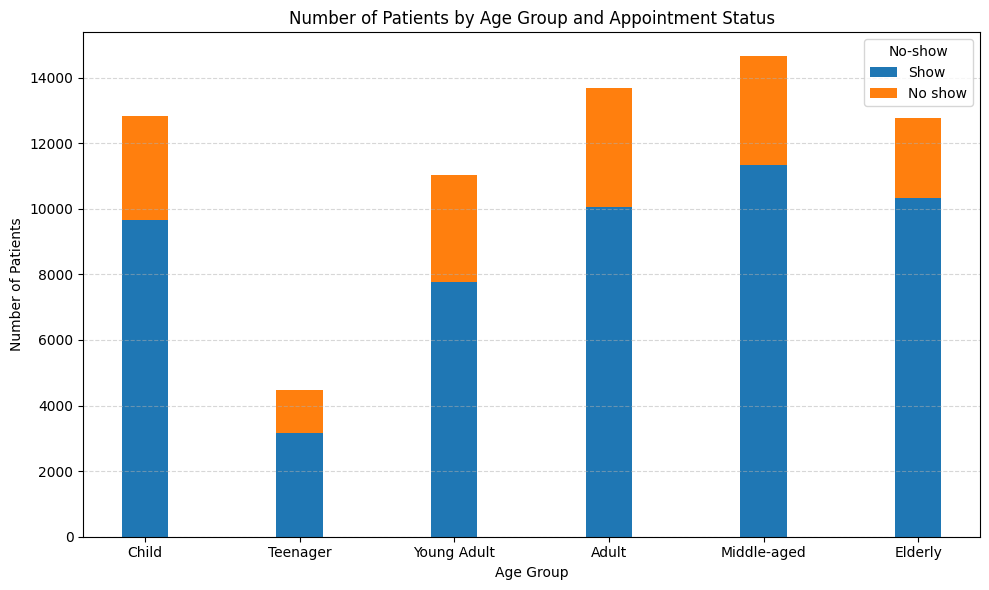

In [66]:
#Group patients into group by age
bins = [0,13,18,30,45,60,115]
labels = ['Child','Teenager','Young Adult','Adult','Middle-aged','Elderly']
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'],bins=bins,labels=labels).astype('object')

#the bar graph shows patients who showed up vs. missed their appointments by age group
age_noshow = df_cleaned.groupby(['Age_Group','No_show']).size().unstack().reindex(labels)
fig, ax = plt.subplots(figsize=(10, 6))
age_noshow.plot(kind='bar', stacked=True, ax=ax, width=0.3)
plt.title('Number of Patients by Age Group and Appointment Status')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='No-show', labels=['Show', 'No show'])
plt.xticks(rotation=0)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

In [67]:
#Number of patients who missed their appointments by age group
df_cleaned.groupby('Age_Group')['No_show'].value_counts().unstack()

No_show,0,1
Age_Group,,
Adult,10051,3639
Child,9665,3162
Elderly,10322,2444
Middle-aged,11337,3309
Teenager,3171,1290
Young Adult,7779,3244


In [68]:
#Proportion of patients who missed their appointments by age group
df_cleaned[df_cleaned['No_show'] == 1]['Age_Group'].value_counts(normalize=True)*100

Age_Group
Adult          21.295646
Middle-aged    19.364466
Young Adult    18.984082
Child          18.504213
Elderly        14.302434
Teenager        7.549157
Name: proportion, dtype: float64

### 4. Do most patients who missed their appointments have any health conditions?

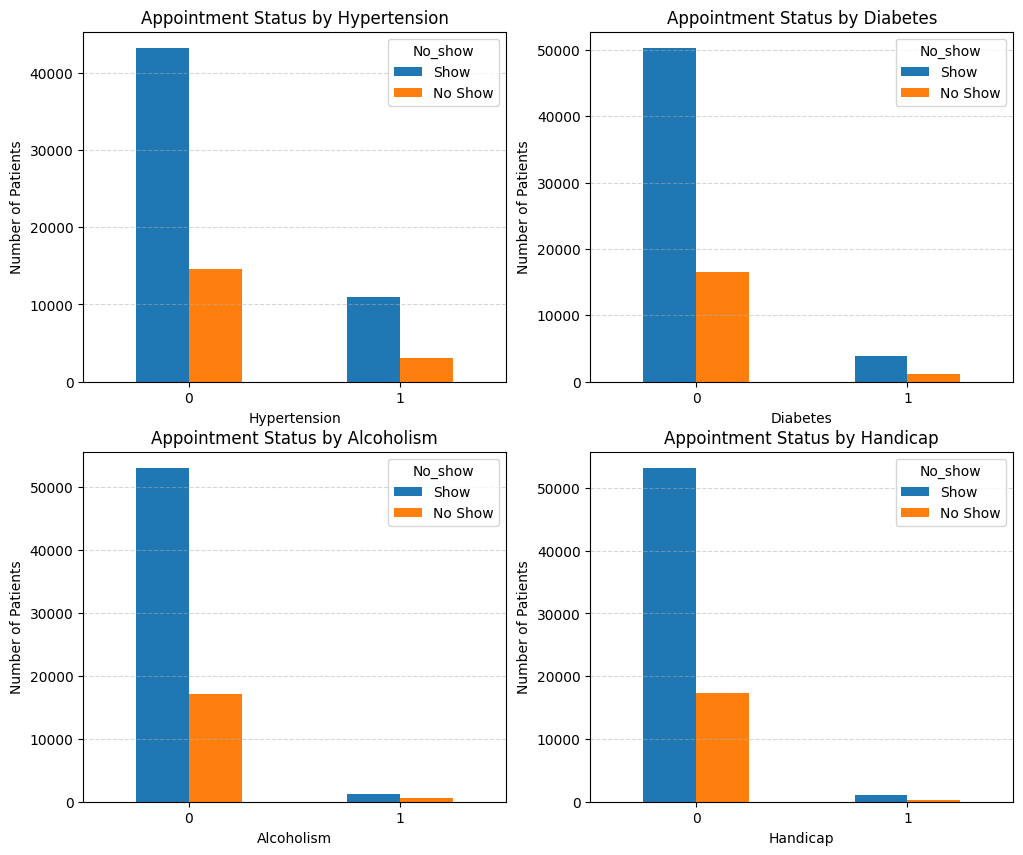

In [69]:
health_condition = ['Hypertension','Diabetes','Alcoholism','Handicap']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

#the bar graph shows patients who showed up vs. missed their appointments by health condition
for i, col in enumerate(health_condition):
    ax = axes[i]
    health_noshow = df_cleaned.groupby(col)['No_show'].value_counts().unstack()
    health_noshow.plot(kind='bar', ax=ax)
    ax.set_title(f'Appointment Status by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Patients')
    ax.tick_params(axis='x', labelrotation=0)
    ax.legend(title='No_show',labels=['Show','No Show'])
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
plt.show()

In [70]:
#Select the patients who have at least one health condition and no-show
health_condition = no_show.query('Hypertension + Diabetes + Alcoholism + Handicap > 0')

#Find the percantage from the patients who have health condition and who not 
percentage = (health_condition.shape[0] / no_show.shape[0])*100
print(f'{percentage:.2f}%')

21.08%


### 5. How many days do patients who missed their appointments have to wait from scheduling to the actual appointment date?

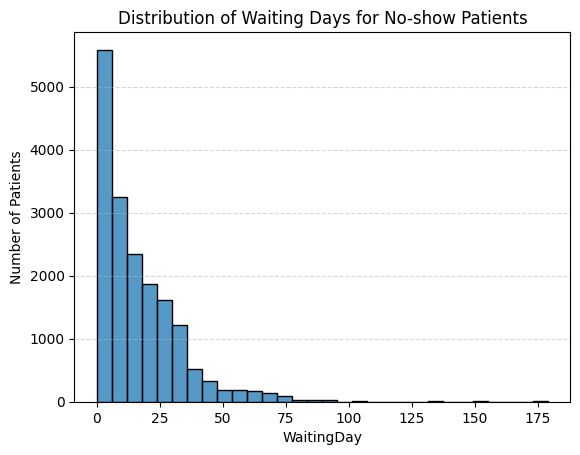

In [71]:
#The graph show number of patients who missed their appointment by WaitingDay
sns.histplot(data=no_show,x='WaitingDay',bins=30)
plt.title('Distribution of Waiting Days for No-show Patients')
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [72]:
#Proportion of patients who missed their appointment by WaitingDay
no_show['WaitingDay'].value_counts(normalize=True)*100

WaitingDay
2      7.491082
0      6.624766
4      5.622558
7      5.565936
1      5.084650
         ...   
102    0.005662
111    0.005662
169    0.005662
151    0.005662
98     0.005662
Name: proportion, Length: 108, dtype: float64

### 6. Which day do most patients miss their appointments?

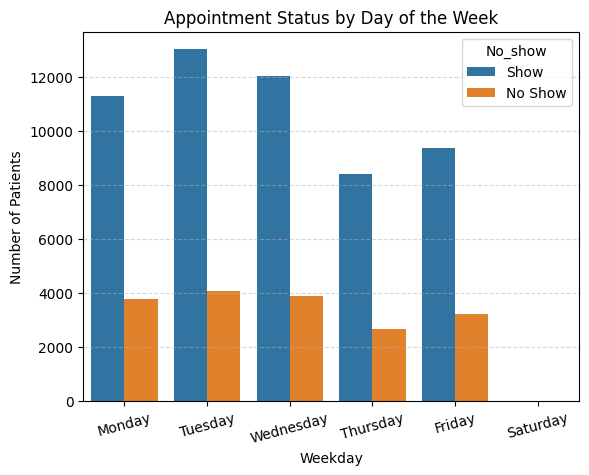

In [73]:
#The graph show number of patients who missed their appointment by Day
weekday = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.countplot(data=df_cleaned,x='Weekday',hue='No_show',order=weekday)
plt.title('Appointment Status by Day of the Week')
plt.ylabel('Number of Patients')
plt.xticks(rotation=15)
plt.legend(title='No_show',labels=['Show','No Show'])
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [74]:
#Proportion of patients who missed their appointment by Day
df_cleaned.groupby('No_show')['Weekday'].value_counts(normalize=True)

No_show  Weekday  
0        Tuesday      0.240319
         Wednesday    0.222185
         Monday       0.208742
         Friday       0.173268
         Thursday     0.155079
         Saturday     0.000406
1        Tuesday      0.230678
         Wednesday    0.221052
         Monday       0.215277
         Friday       0.182040
         Thursday     0.150614
         Saturday     0.000340
Name: proportion, dtype: float64

### 7. Does receiving an SMS reminder influence the likelihood of attending the appointment?

In [84]:
#Number of patients who received and not received SMS
df_cleaned['SMS_received'].value_counts(normalize=True)

SMS_received
0    0.664425
1    0.335575
Name: proportion, dtype: float64

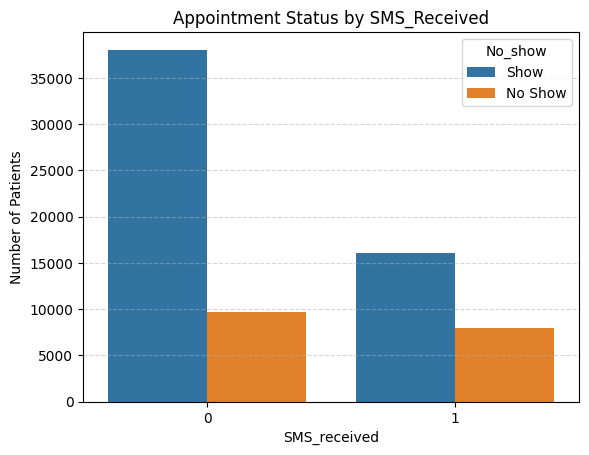

In [76]:
#The graph show number of patients who showed up vs. missed their appointments by SMS received
sns.countplot(data=df_cleaned,x='SMS_received',hue='No_show')
plt.title('Appointment Status by SMS_Received')
plt.legend(title='No_show',labels=['Show','No Show'])
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [77]:
#Proportion of patients who showed up vs. missed their appointments by SMS received
df_cleaned.groupby('SMS_received')['No_show'].value_counts(normalize=True)

SMS_received  No_show
0             0          0.797590
              1          0.202410
1             0          0.667912
              1          0.332088
Name: proportion, dtype: float64

### 8. Which neighborhood has the highest number of patients who missed their appointments and did they receive SMS reminder?

In [78]:
#Number of total neighbourhood
df_cleaned['Neighbourhood'].nunique()

81

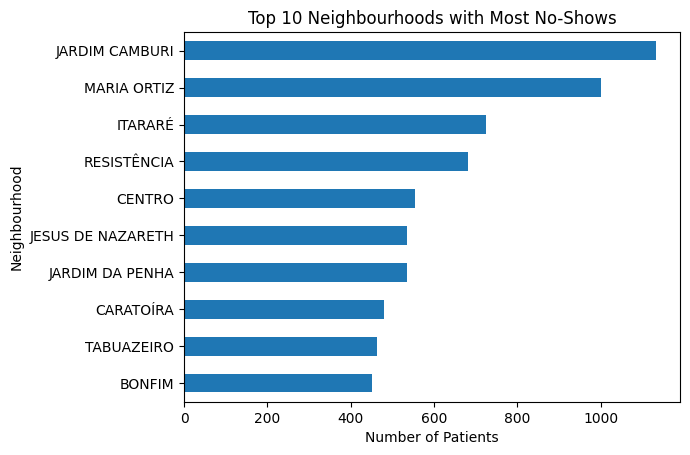

In [79]:
#the graph shows top 10 neighbourhoods that have the most number of patients who missed their appointment
top10_neighbour = no_show['Neighbourhood'].value_counts().head(10).sort_values()

top10_neighbour.plot(kind='barh')
plt.title('Top 10 Neighbourhoods with Most No-Shows')
plt.xlabel('Number of Patients')
plt.show()

In [80]:
#Proportion of top 10 neighbourhoods
top10_neighbour_percentage = round(no_show['Neighbourhood'].value_counts(normalize=True).head(10)*100,2)
print(top10_neighbour_percentage)

Neighbourhood
JARDIM CAMBURI       6.42
MARIA ORTIZ          5.66
ITARARÉ              4.11
RESISTÊNCIA          3.86
CENTRO               3.14
JARDIM DA PENHA      3.03
JESUS DE NAZARETH    3.03
CARATOÍRA            2.71
TABUAZEIRO           2.63
BONFIM               2.55
Name: proportion, dtype: float64


SMS_received
0    0.540924
1    0.459076
Name: proportion, dtype: float64


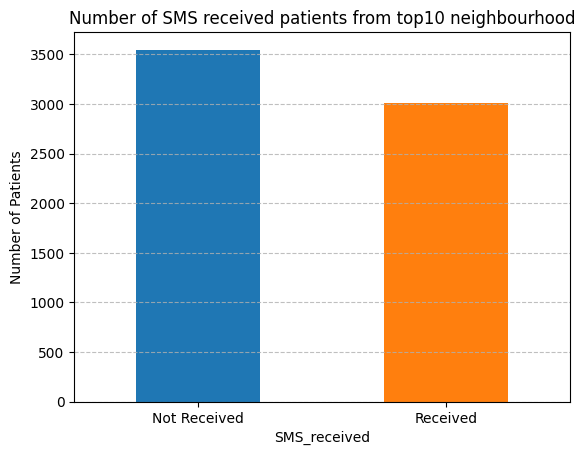

In [81]:
#Did these neighbourhood received SMS reminder?
#Number of SMS received patients from top 10 neighbourhood
top10_list = list(top10_neighbour_percentage.index)
top10_neighbour = no_show.loc[no_show['Neighbourhood'].isin(top10_list)]

print(no_show.loc[no_show['Neighbourhood'].isin(top10_list)].value_counts('SMS_received',normalize=True))

top10_neighbour.value_counts('SMS_received').plot(kind='bar',color=['tab:blue','tab:orange'])
plt.title('Number of SMS received patients from top10 neighbourhood')
plt.xticks(ticks=[0,1],labels=['Not Received','Received'],rotation=0)
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.8)
plt.show()

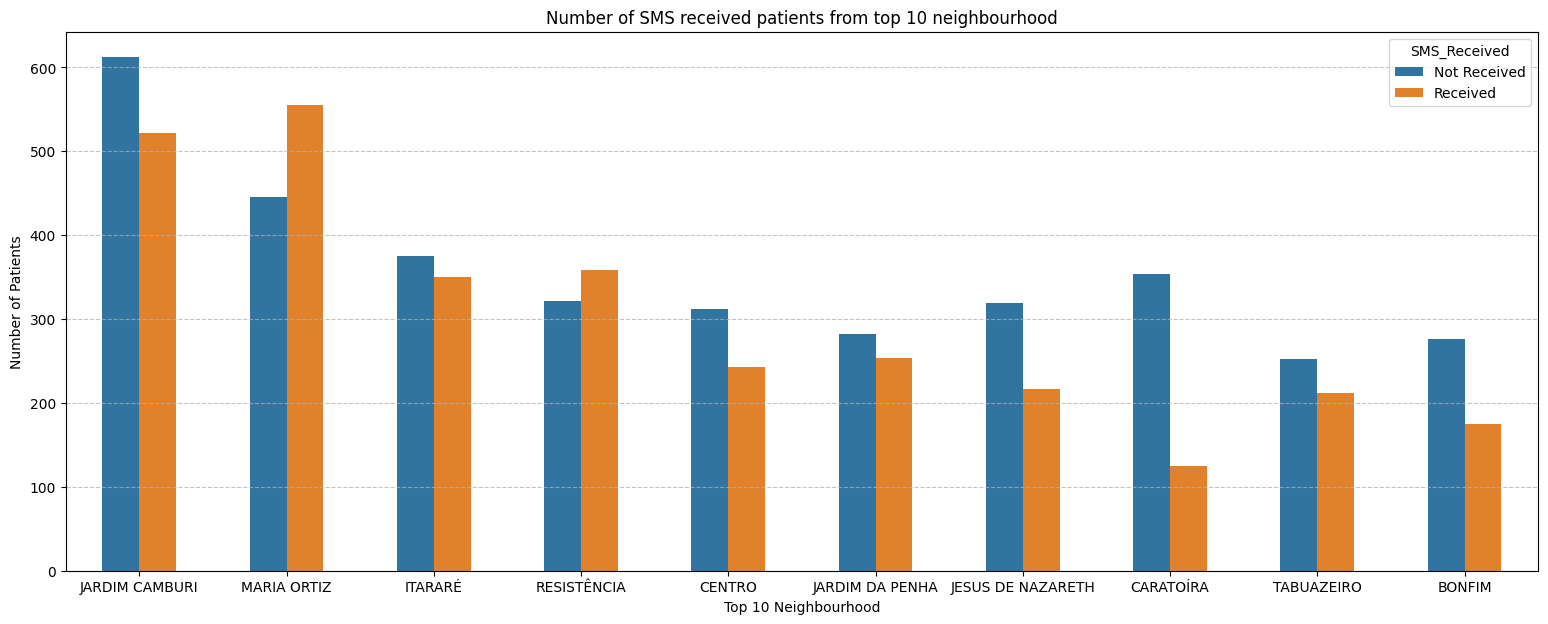

In [82]:
#Number of SMS received patients from each neighbourhood
plt.figure(figsize=(19,7))
sns.countplot(data=top10_neighbour,x='Neighbourhood',hue='SMS_received',width=0.5,order=top10_list)
plt.title('Number of SMS received patients from top 10 neighbourhood')
plt.xlabel('Top 10 Neighbourhood')
plt.ylabel('Number of Patients')
plt.grid(axis='y',linestyle='--',alpha=0.75)
plt.legend(title='SMS_Received',labels=['Not Received','Received'])
plt.show()

## Summary

* **Appointment Status:** 75.4% of patients showed up for their appointments, while 24.6% missed them.

* **Gender:** The total number of female patients who missed their appointments is higher than the total number of male patients, which is consistent with the overall higher number of female patients in the dataset. However, when considering the no-show rate within each gender, both male and female patients have a similar no-show rate of approximately 24%.

* **Age Group:** Among all patients, the majority were middle-aged adults (45-60 years). However, when looking specifically at the patients who missed their appointments, the highest proportion came from adult group (30-45 years) at 21.3% of all no-shows, followed by the middle-aged group at 19.36%.

* **Health Conditions:** Among the patients who missed their appointment, 21.08% had at least one health condition.

* **Waiting Time:** The highest number of missed appointments occurred among patients who had to wait 2 days between scheduling and the actual appointment date.

* **Day of Appointment:** Tuesday has the highest number of missed appointments.

* **SMS Reminder:** 33.56% of patients received SMS reminders. Surprisingly, the no-show rate among this group was 33.21%, while the no-show rate among patients who didn't receive SMS reminders was only 20.2%.

* **Neighbourhood:** The neighbourhood with the highest number of no-show patients is **Jardim Camburi** at 6.42% of all patients from 81 neighbourhoods.

* **Top 10 Neighbourhoods:** Among the top 10 neighbourhoods with the highest number of no-shows, 45.9% of patients who missed their appointments received SMS reminders. Futhermore, in Maria Ortiz and Resistência, the number of no-show patients who received SMS reminders was even higher than the patients who did not receive SMS reminder.


## Suggestion

1. Focus on patients aged 30-45, as this group has the highest rate of missed appointments. Recommended to improve appointment reminders to better suit the behaviors of this age group.

2. Conduct further research to identify additional factors that may influence appointment attendance. Although no clear relationship was found between gender or health conditions and missed appointments, other factors such as family size or education, income levels may contribute and should be explored.
   
3. Closely track and analyze the Jardim Camburi and other high no-show neighbourhoods. Analyze potential causes, such as transportation difficulties or geographical constraints, and use them to support more targeted interventions.

4. Optimize the SMS reminder system such as the accuracy of contact numbers, optimize the timing, frequency, and content of reminder messages, to improve SMS reminders efficency, as the data shows that patients who received SMS reminders still had a higher no-show rate than those who did not.